# Genetic Algorithm

This notebook/script implements the genetic algorithm requested in the PDF.
It:

1. Parses the input file.
2. Decodes 5-bit chromosomes into decimal values.
3. Evaluates fitness using f(x) = x^2.
4. Uses roulette wheel selection, single-point crossover, and bit-flip mutation.
5. Preserves the best chromosome through elitism.
6. Plots best and average fitness across generations.

In [2]:
from __future__ import annotations

import argparse
import re
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SAMPLE_INPUT_TEXT = """Population Size = 10
Chromosome Length = 5 bits
Fitness Function: f(x) = x^2
Parameters: Pc = 0.8 Pm = 0.01 Generations = 50
Initial Population: 10101 00111 11100 01010 10011 01101 11001 00011 11111 00101
"""


@dataclass(frozen=True)
class GAConfig:
    population_size: int = 10
    chromosome_length: int = 5
    crossover_probability: float = 0.8
    mutation_probability: float = 0.01
    generations: int = 50
    seed: int = 16


@dataclass(frozen=True)
class GARunResult:
    """Container for a complete GA run."""

    config: GAConfig
    initial_population: list[str]
    final_population: list[str]
    history: pd.DataFrame
    output_path: Path
    plot_dir: Path

In [3]:
def decode_chromosome(chromosome: str) -> int:
    """Convert a binary chromosome into its decimal value."""

    return int(chromosome, 2)


def fitness_function(x: int) -> int:
    """Fitness function requested by the assignment."""

    return x * x


def chromosome_fitness(chromosome: str) -> int:
    """Return the fitness of a chromosome."""

    return fitness_function(decode_chromosome(chromosome))


def normalize_chromosome(chromosome: str, chromosome_length: int) -> str:
    """Validate and normalize a chromosome string."""

    chromosome = chromosome.strip()
    if not chromosome:
        raise ValueError("Encountered an empty chromosome.")
    if len(chromosome) != chromosome_length:
        raise ValueError(
            f"Chromosome {chromosome!r} must have length {chromosome_length}."
        )
    if re.fullmatch(rf"[01]{{{chromosome_length}}}", chromosome) is None:
        raise ValueError(f"Chromosome {chromosome!r} must contain only 0/1 bits.")
    return chromosome


def extract_int(text: str, pattern: str, default: int) -> int:
    match = re.search(pattern, text, flags=re.IGNORECASE | re.MULTILINE)
    return int(match.group(1)) if match else default


def extract_float(text: str, pattern: str, default: float) -> float:
    match = re.search(pattern, text, flags=re.IGNORECASE | re.MULTILINE)
    if not match:
        return default
    value = float(match.group(1))
    if "%" in match.group(0):
        value /= 100.0
    return value

In [4]:
def extract_initial_population(text: str, chromosome_length: int) -> list[str]:
    """Find the initial population section and extract binary chromosomes."""

    initial_match = re.search(
        r"Initial\s+Population\s*[:=]\s*(.*)",
        text,
        flags=re.IGNORECASE | re.DOTALL,
    )
    population_block = initial_match.group(1) if initial_match else text

    cutoff_match = re.search(
        r"(?:Sample\s+Output|Expected\s+Deliverables|Deliverables|Output\s+)"
        r"\b",
        population_block,
        flags=re.IGNORECASE | re.DOTALL,
    )
    if cutoff_match:
        population_block = population_block[: cutoff_match.start()]

    chromosomes = re.findall(rf"(?<![01])[01]{{{chromosome_length}}}(?![01])", population_block)
    if not chromosomes:
        chromosomes = re.findall(rf"(?<![01])[01]{{{chromosome_length}}}(?![01])", text)
    return chromosomes


def parse_input_text(text: str, default_config: GAConfig | None = None) -> tuple[GAConfig, list[str]]:
    """Parse the assignment input format from plain text."""

    default_config = default_config or GAConfig()

    population_size = extract_int(
        text,
        r"Population\s+Size\s*=\s*(\d+)",
        default_config.population_size,
    )
    chromosome_length = extract_int(
        text,
        r"Chromosome\s+Length\s*=\s*(\d+)",
        default_config.chromosome_length,
    )
    crossover_probability = extract_float(
        text,
        r"(?:Pc|Crossover\s+Probability)\s*=\s*([0-9]*\.?[0-9]+)",
        default_config.crossover_probability,
    )
    mutation_probability = extract_float(
        text,
        r"(?:Pm|Mutation\s+Probability)\s*=\s*([0-9]*\.?[0-9]+)",
        default_config.mutation_probability,
    )
    generations = extract_int(
        text,
        r"Generations\s*=\s*(\d+)",
        default_config.generations,
    )
    seed = extract_int(text, r"Seed\s*=\s*(\d+)", default_config.seed)

    initial_population = extract_initial_population(text, chromosome_length)
    if not initial_population:
        raise ValueError("No binary chromosomes were found in the input text.")

    normalized_population = [
        normalize_chromosome(chromosome, chromosome_length)
        for chromosome in initial_population
    ]

    rng = np.random.default_rng(seed)
    while len(normalized_population) < population_size:
        filler = "".join(rng.choice(["0", "1"], size=chromosome_length).tolist())
        normalized_population.append(filler)
    normalized_population = normalized_population[:population_size]

    config = GAConfig(
        population_size=population_size,
        chromosome_length=chromosome_length,
        crossover_probability=crossover_probability,
        mutation_probability=mutation_probability,
        generations=generations,
        seed=seed,
    )
    return config, normalized_population


def parse_input_file(path: Path, default_config: GAConfig | None = None) -> tuple[GAConfig, list[str]]:
    """Read and parse an assignment input file."""

    text = path.read_text(encoding="utf-8")
    return parse_input_text(text, default_config=default_config)

In [5]:
def roulette_wheel_selection(
    population: Sequence[str],
    fitness_values: Sequence[int],
    rng: np.random.Generator,
) -> str:
    """Select one chromosome using roulette wheel selection."""

    weights = np.asarray(fitness_values, dtype=float)
    total = weights.sum()
    if total <= 0:
        probabilities = np.full(len(population), 1.0 / len(population))
    else:
        probabilities = weights / total
    index = int(rng.choice(len(population), p=probabilities))
    return population[index]


def single_point_crossover(
    parent_a: str,
    parent_b: str,
    crossover_probability: float,
    rng: np.random.Generator,
) -> tuple[str, str]:
    """Apply single-point crossover to two parents."""

    if len(parent_a) != len(parent_b):
        raise ValueError("Parents must have the same chromosome length.")
    if len(parent_a) < 2 or rng.random() >= crossover_probability:
        return parent_a, parent_b

    point = int(rng.integers(1, len(parent_a)))
    child_a = parent_a[:point] + parent_b[point:]
    child_b = parent_b[:point] + parent_a[point:]
    return child_a, child_b


def bit_flip_mutation(
    chromosome: str,
    mutation_probability: float,
    rng: np.random.Generator,
) -> str:
    """Flip each bit independently with the given mutation probability."""

    bits = list(chromosome)
    for index, bit in enumerate(bits):
        if rng.random() < mutation_probability:
            bits[index] = "1" if bit == "0" else "0"
    return "".join(bits)


def summarize_population(population: Sequence[str]) -> tuple[str, int, int, float]:
    """Return the best chromosome, its decimal value, fitness, and the mean fitness."""

    fitness_values = [chromosome_fitness(chromosome) for chromosome in population]
    best_index = int(np.argmax(fitness_values))
    best_chromosome = population[best_index]
    best_value = decode_chromosome(best_chromosome)
    best_fitness = fitness_values[best_index]
    average_fitness = float(np.mean(fitness_values))
    return best_chromosome, best_value, best_fitness, average_fitness

In [6]:
def format_population_table(population: Sequence[str]) -> list[str]:
    """Create the generation-0 table shown in the report."""

    lines = [
        "-" * 56,
        "Chromosome      Decimal(x)     Fitness f(x)=x^2",
        "-" * 56,
    ]
    for chromosome in population:
        value = decode_chromosome(chromosome)
        fitness = fitness_function(value)
        lines.append(f"{chromosome:<15}{value:<14}{fitness}")
    return lines


def run_genetic_algorithm(
    initial_population: Sequence[str],
    config: GAConfig,
) -> tuple[list[str], pd.DataFrame]:
    """Execute the GA for the requested number of generations."""

    population = list(initial_population)
    rng = np.random.default_rng(config.seed)
    history_rows: list[dict[str, object]] = []

    for generation in range(config.generations + 1):
        fitness_values = [chromosome_fitness(chromosome) for chromosome in population]
        best_index = int(np.argmax(fitness_values))
        best_chromosome = population[best_index]
        best_value = decode_chromosome(best_chromosome)
        best_fitness = fitness_values[best_index]
        average_fitness = float(np.mean(fitness_values))
        history_rows.append(
            {
                "Generation": generation,
                "BestChromosome": best_chromosome,
                "BestValue": best_value,
                "BestFitness": best_fitness,
                "AverageFitness": average_fitness,
            }
        )

        if generation == config.generations:
            break

        next_population: list[str] = []
        while len(next_population) < config.population_size:
            parent_a = roulette_wheel_selection(population, fitness_values, rng)
            parent_b = roulette_wheel_selection(population, fitness_values, rng)
            child_a, child_b = single_point_crossover(
                parent_a,
                parent_b,
                config.crossover_probability,
                rng,
            )
            child_a = bit_flip_mutation(child_a, config.mutation_probability, rng)
            child_b = bit_flip_mutation(child_b, config.mutation_probability, rng)
            next_population.extend([child_a, child_b])

        next_population = next_population[: config.population_size]

        elite_index = int(np.argmax(fitness_values))
        elite_chromosome = population[elite_index]
        child_fitness_values = [chromosome_fitness(chromosome) for chromosome in next_population]
        worst_index = int(np.argmin(child_fitness_values))
        next_population[worst_index] = elite_chromosome
        population = next_population

    history = pd.DataFrame(history_rows)
    return population, history

In [7]:
def build_output_report(
    input_path: Path,
    config: GAConfig,
    initial_population: Sequence[str],
    history: pd.DataFrame,
    final_population: Sequence[str],
) -> str:
    """Build the text report written to outputPS16.txt."""

    initial_best, _, initial_best_fitness, initial_average = summarize_population(initial_population)
    final_best = history.iloc[-1]["BestChromosome"]
    final_value = int(history.iloc[-1]["BestValue"])
    final_fitness = int(history.iloc[-1]["BestFitness"])

    lines: list[str] = []
    lines.append("PS16 Genetic Algorithm Report")
    lines.append(f"Input file: {input_path}")
    lines.append("")
    lines.append("Parameters")
    lines.append(f"Population Size       : {config.population_size}")
    lines.append(f"Chromosome Length     : {config.chromosome_length}")
    lines.append(f"Crossover Probability  : {config.crossover_probability}")
    lines.append(f"Mutation Probability   : {config.mutation_probability}")
    lines.append(f"Generations            : {config.generations}")
    lines.append(f"Seed                   : {config.seed}")
    lines.append("")
    lines.append("Generation 0")
    lines.extend(format_population_table(initial_population))
    lines.append("")
    lines.append(f"Best Chromosome: {initial_best}")
    lines.append(f"Best Fitness: {initial_best_fitness}")
    lines.append(f"Average Fitness: {initial_average:.1f}")
    lines.append("-" * 56)
    lines.append("")
    lines.append("Generation Progress")
    lines.append("Gen   BestChromosome   BestX   BestFitness   AverageFitness")
    lines.append("-" * 56)
    for row in history.itertuples(index=False):
        lines.append(
            f"{int(row.Generation):<5}"
            f"{str(row.BestChromosome):<16}"
            f"{int(row.BestValue):<8}"
            f"{int(row.BestFitness):<13}"
            f"{float(row.AverageFitness):.1f}"
        )
    lines.append("-" * 56)
    lines.append("")
    lines.append(f"After {config.generations} Generations")
    lines.append(f"Best Chromosome: {final_best}")
    lines.append(f"Decoded Value (x): {final_value}")
    lines.append(f"Maximum Fitness: {final_fitness}")
    lines.append(f"Final Population Sample: {'  '.join(final_population)}")
    lines.append("")
    lines.append("Observations")
    lines.append("- Roulette wheel selection consistently prefers high-fitness chromosomes.")
    lines.append("- Elitism keeps the best solution from being lost during evolution.")
    lines.append("- Mutation preserves diversity and prevents early stagnation.")
    return "\n".join(lines) + "\n"

In [8]:
def plot_history(history: pd.DataFrame, plot_dir: Path) -> tuple[Path, Path]:
    """Plot best and average fitness versus generation."""

    plot_dir.mkdir(parents=True, exist_ok=True)

    best_plot = plot_dir / "best_fitness_vs_generation.png"
    average_plot = plot_dir / "average_fitness_vs_generation.png"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        history["Generation"],
        history["BestFitness"],
        color="#1f77b4",
        marker="o",
        linewidth=2,
        label="Best Fitness",
    )
    ax.set_title("Best Fitness vs Generation")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(best_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        history["Generation"],
        history["AverageFitness"],
        color="#ff7f0e",
        marker="o",
        linewidth=2,
        label="Average Fitness",
    )
    ax.set_title("Average Fitness vs Generation")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(average_plot, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return best_plot, average_plot

In [9]:
def run_assignment(
    input_path: Path,
    output_path: Path,
    plot_dir: Path,
    seed: int | None = None,
) -> GARunResult:
    """Run the assignment end to end and return the artefacts."""

    default_config = GAConfig()
    if input_path.exists():
        config, initial_population = parse_input_file(input_path, default_config)
    else:
        config, initial_population = parse_input_text(SAMPLE_INPUT_TEXT, default_config)

    if seed is not None:
        config = replace(config, seed=seed)

    final_population, history = run_genetic_algorithm(initial_population, config)
    report = build_output_report(input_path, config, initial_population, history, final_population)
    output_path.write_text(report, encoding="utf-8")
    best_plot, average_plot = plot_history(history, plot_dir)

    print(report)
    print(f"Saved plots: {best_plot}")
    print(f"Saved plots: {average_plot}")

    return GARunResult(
        config=config,
        initial_population=list(initial_population),
        final_population=list(final_population),
        history=history,
        output_path=output_path,
        plot_dir=plot_dir,
    )

## Short Report Notes

- Roulette wheel selection gives fitter chromosomes a higher chance of reproduction.
- Single-point crossover combines good partial solutions from two parents.
- Bit-flip mutation maintains diversity and helps the population escape local stagnation.
- Elitism keeps the best chromosome from being lost between generations.

In [10]:
def main(argv: Sequence[str] | None = None) -> int:
    """CLI entry point."""

    parser = argparse.ArgumentParser(description="Solve PS16 using a genetic algorithm.")
    parser.add_argument("--input", type=Path, default=Path("inputPS16.txt"))
    parser.add_argument("--output", type=Path, default=Path("outputPS16.txt"))
    parser.add_argument("--plots", type=Path, default=Path("outputs") / "ps16")
    parser.add_argument("--seed", type=int, default=None, help="Optional override for the random seed.")
    args, _unknown = parser.parse_known_args(argv)

    run_assignment(args.input, args.output, args.plots, seed=args.seed)
    return 0

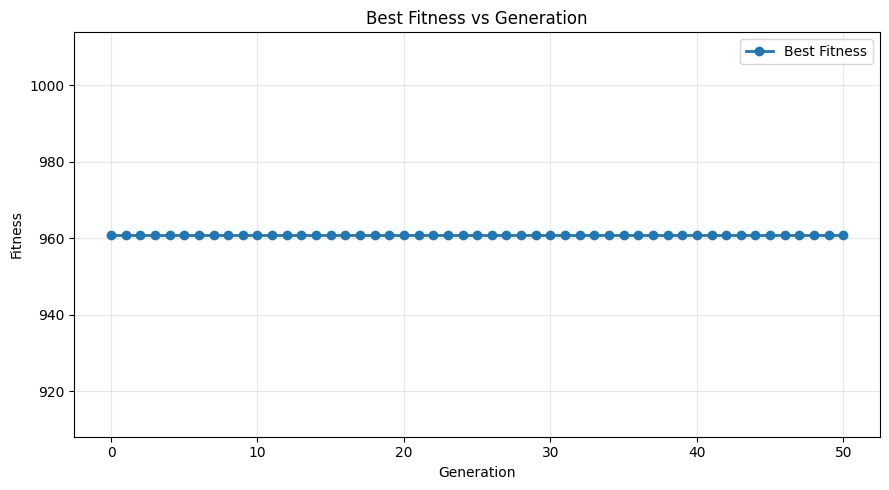

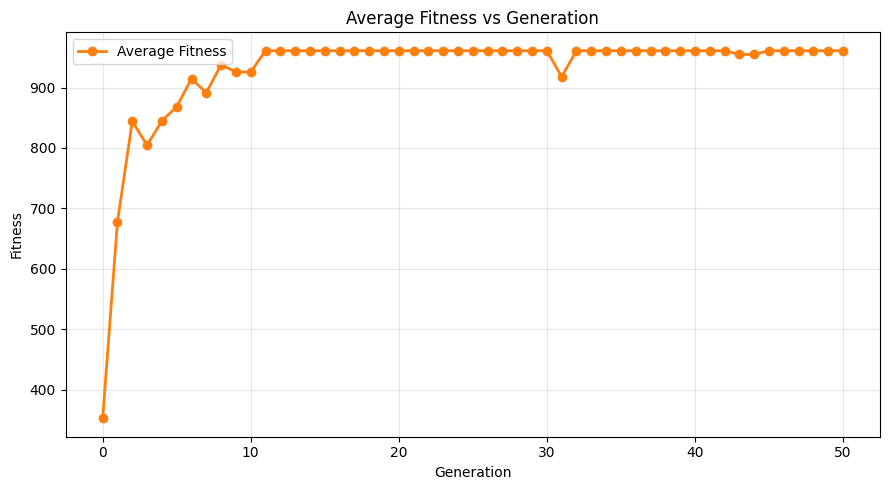

PS16 Genetic Algorithm Report
Input file: inputPS16.txt

Parameters
Population Size       : 10
Chromosome Length     : 5
Crossover Probability  : 0.8
Mutation Probability   : 0.01
Generations            : 50
Seed                   : 16

Generation 0
--------------------------------------------------------
Chromosome      Decimal(x)     Fitness f(x)=x^2
--------------------------------------------------------
10101          21            441
00111          7             49
11100          28            784
01010          10            100
10011          19            361
01101          13            169
11001          25            625
00011          3             9
11111          31            961
00101          5             25

Best Chromosome: 11111
Best Fitness: 961
Average Fitness: 352.4
--------------------------------------------------------

Generation Progress
Gen   BestChromosome   BestX   BestFitness   AverageFitness
--------------------------------------------------------
0 

In [11]:
if __name__ == "__main__":
    main()